In [27]:
!pip install pandas==2.2.2
!pip install seaborn==0.13.2

In [28]:
# this is an install from "https://www.kaggle.com/datasets/willianoliveiragibin/fatalities-in-the-israeli-palestinian"
# this is so i can easily import the CSV file
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the specific file you'd like to load
# The empty string caused the extension error; it needs the actual filename.
file_path = "fatalities_isr_pse_conflict_2000_to_2023.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "willianoliveiragibin/fatalities-in-the-israeli-palestinian",
  file_path
)

# below is to see if data will be executed

print("First 5 records:")
print(df.head())

Using Colab cache for faster access to the 'fatalities-in-the-israeli-palestinian' dataset.
First 5 records:
                                          name date_of_event   age  \
0  'Abd a-Rahman Suleiman Muhammad Abu Daghash    2023-09-24  32.0   
1         Usayed Farhan Muhammad 'Ali Abu 'Ali    2023-09-24  21.0   
2             'Abdallah 'Imad Sa'ed Abu Hassan    2023-09-22  16.0   
3             Durgham Muhammad Yihya al-Akhras    2023-09-20  19.0   
4                 Raafat 'Omar Ahmad Khamaisah    2023-09-19  15.0   

   citizenship     event_location event_location_district  \
0  Palestinian     Nur Shams R.C.                 Tulkarm   
1  Palestinian     Nur Shams R.C.                 Tulkarm   
2  Palestinian           Kfar Dan                   Jenin   
3  Palestinian  'Aqbat Jaber R.C.                 Jericho   
4  Palestinian         Jenin R.C.                   Jenin   

  event_location_region date_of_death gender took_part_in_the_hostilities  \
0             West Bank   

 **Inquiry: Which ethnic group of people have died on Palestian land(colonized by Israel) and by the hands of who?**

In [29]:
df.describe()

,age
count,10995.000000
mean,26.745703
std,13.780548
min,1.000000
25%,19.000000
50%,23.000000
75%,31.000000
max,112.000000


In [30]:
df.head()

,name,date_of_event,age,citizenship,event_location,event_location_district,event_location_region,date_of_death,gender,took_part_in_the_hostilities,place_of_residence,place_of_residence_district,type_of_injury,ammunition,killed_by,notes
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,2023-09-24,32.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while standing ...
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,2023-09-24,21.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while trying to...
2,'Abdallah 'Imad Sa'ed Abu Hassan,2023-09-22,16.0,Palestinian,Kfar Dan,Jenin,West Bank,2023-09-22,M,NaN,al-Yamun,Jenin,gunfire,live ammunition,Israeli security forces,Fatally shot by soldiers while firing at them ...
3,Durgham Muhammad Yihya al-Akhras,2023-09-20,19.0,Palestinian,'Aqbat Jaber R.C.,Jericho,West Bank,2023-09-20,M,NaN,'Aqbat Jaber R.C.,Jericho,gunfire,live ammunition,Israeli security forces,Shot in the head by Israeli forces while throw...
4,Raafat 'Omar Ahmad Khamaisah,2023-09-19,15.0,Palestinian,Jenin R.C.,Jenin,West Bank,2023-09-19,M,NaN,Jenin,Jenin,gunfire,live ammunition,Israeli security forces,Wounded by soldiers’ gunfire after running awa...


In [31]:
columns = ['name', 'age', 'citizenship', 'killed_by']
df[columns].head(10)

# unifying stats that i think are the most poignant

df[['name', 'age', 'citizenship', 'killed_by']].head(n=10)

,name,age,citizenship,killed_by
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,32.0,Palestinian,Israeli security forces
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,21.0,Palestinian,Israeli security forces
2,'Abdallah 'Imad Sa'ed Abu Hassan,16.0,Palestinian,Israeli security forces
3,Durgham Muhammad Yihya al-Akhras,19.0,Palestinian,Israeli security forces
4,Raafat 'Omar Ahmad Khamaisah,15.0,Palestinian,Israeli security forces
5,'Ata Yasser 'Ata Musa,29.0,Palestinian,Israeli security forces
6,Yusef Salem Yusef Radwan,24.0,Palestinian,Israeli security forces
7,Mahmoud Khaled S'ud 'Ar'arawi,25.0,Palestinian,Israeli security forces
8,Mahmoud 'Ali Nafe'a a-S'adi,23.0,Palestinian,Israeli security forces
9,Milad Munzer Wajih a-Ra'i,15.0,Palestinian,Israeli security forces


In [32]:
print("*** Missing age Mask : Start ***")
# Generate a mask for rows based on recorded age.
# A mask has the same number of rows as the original data.
# It acts like a filter where:
#   A False means age is not missing, i.e., has a recorded age.
#   A True means age is missing.
# Note: Changed 'Age' to 'age' to match the dataframe column name.
rows_missing_age_mask = df["age"].isna()
print(rows_missing_age_mask)

print("*** Missing Age Mask : End  ***\n\n")

rows_missing_age = df[rows_missing_age_mask]
print(f"{len(rows_missing_age)} records have no recorded age.")

*** Missing age Mask : Start ***
0        False
1        False
2        False
3        False
4        False
         ...  
11119    False
11120    False
11121    False
11122    False
11123    False
Name: age, Length: 11124, dtype: bool
*** Missing Age Mask : End  ***


129 records have no recorded age.


In [33]:
df["age"], df["citizenship"], df["killed_by"]

(0        32.0
 1        21.0
 2        16.0
 3        19.0
 4        15.0
          ... 
 11119    64.0
 11120    28.0
 11121    36.0
 11122    21.0
 11123    24.0
 Name: age, Length: 11124, dtype: float64,
 0        Palestinian
 1        Palestinian
 2        Palestinian
 3        Palestinian
 4        Palestinian
             ...     
 11119        Israeli
 11120    Palestinian
 11121        Israeli
 11122    Palestinian
 11123        Israeli
 Name: citizenship, Length: 11124, dtype: object,
 0        Israeli security forces
 1        Israeli security forces
 2        Israeli security forces
 3        Israeli security forces
 4        Israeli security forces
                   ...           
 11119      Palestinian civilians
 11120          Israeli civilians
 11121      Palestinian civilians
 11122          Israeli civilians
 11123      Palestinian civilians
 Name: killed_by, Length: 11124, dtype: object)

In [34]:
import pandas as pd

na_filtered = df.isna()
na_count = na_filtered.sum()
na_pct   = (na_filtered.mean()*100).round(1)

pd.DataFrame({"NA count": na_count, "NA %": na_pct})

,NA count,NA %
name,0,0.0
date_of_event,0,0.0
age,129,1.2
citizenship,0,0.0
event_location,0,0.0
event_location_district,0,0.0
event_location_region,0,0.0
date_of_death,0,0.0
gender,20,0.2
took_part_in_the_hostilities,1430,12.9


In [35]:
cleaned_df = df.copy()

# Fill missing age values with the median age
age_median = cleaned_df["age"].median()
cleaned_df.fillna({"age": age_median}, inplace=True)

# Dropping columns you identified as less poignant for this specific analysis
cleaned_df.drop(columns=["citizenship", "killed_by"], inplace=True)

# Removed the 'Embarked' line as it does not exist in this dataset.
# If you wanted to drop rows missing a different value, you could use a column like 'gender'
# cleaned_df.dropna(subset=["gender"], inplace=True)

print(cleaned_df.isna().sum().sum(), "missing cells left in the dataframe.")
display(cleaned_df.head())

7410 missing cells left in the dataframe.


,name,date_of_event,age,event_location,event_location_district,event_location_region,date_of_death,gender,took_part_in_the_hostilities,place_of_residence,place_of_residence_district,type_of_injury,ammunition,notes
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,2023-09-24,32.0,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Fatally shot by Israeli forces while standing ...
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,2023-09-24,21.0,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Fatally shot by Israeli forces while trying to...
2,'Abdallah 'Imad Sa'ed Abu Hassan,2023-09-22,16.0,Kfar Dan,Jenin,West Bank,2023-09-22,M,NaN,al-Yamun,Jenin,gunfire,live ammunition,Fatally shot by soldiers while firing at them ...
3,Durgham Muhammad Yihya al-Akhras,2023-09-20,19.0,'Aqbat Jaber R.C.,Jericho,West Bank,2023-09-20,M,NaN,'Aqbat Jaber R.C.,Jericho,gunfire,live ammunition,Shot in the head by Israeli forces while throw...
4,Raafat 'Omar Ahmad Khamaisah,2023-09-19,15.0,Jenin R.C.,Jenin,West Bank,2023-09-19,M,NaN,Jenin,Jenin,gunfire,live ammunition,Wounded by soldiers’ gunfire after running awa...


<Axes: xlabel='citizenship', ylabel='count'>

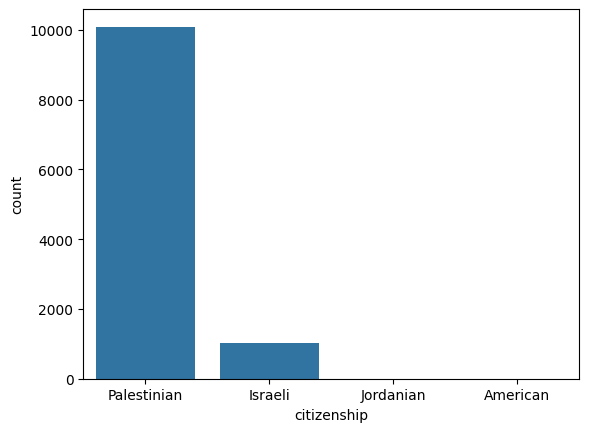

In [37]:
sns.countplot(x="citizenship", data=df)


This chart is to illustrate the ethnic murders that have occurred from October 2000 to show the overall disparity and ethnic targeting. The visual attached to the first one is to show the overview of deaths from before October 7th 2023, the modern genocide of Palestians by Israelis. This data set shares that from 10/01/2000 through 09/23/2023 that, although there had been reported deaths of Israelis, of that 23 year span there were a total of 997 deaths compared to the 10,086 deaths of Palestinians. The count plot visually illustrates that the deaths of Israelis are barely 1/10th of the total passing of Palestinians. Inquiry: I am a part of the leftist action here at the UO, my first year at UO was the encampment and I had participated and now work for several organizations on campus. On the news there is deliberate erasure on the amount of deaths of the active genocide of the Palestian people, I wanted to see how these data points will illustrate that number. The other ethnic groups, Jordanian and American statistics are outliers of the total amount collectively representing three plots.


<Axes: xlabel='citizenship', ylabel='Count'>

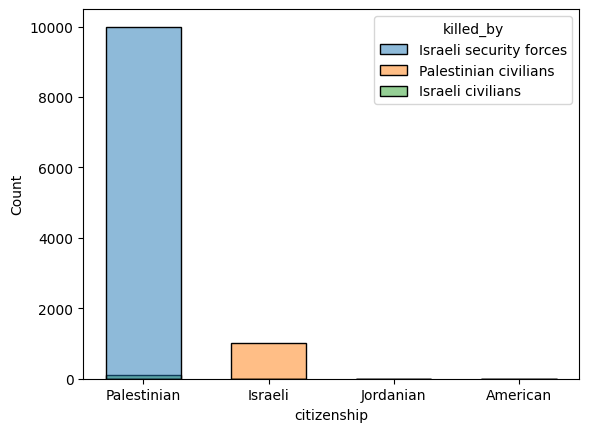

In [38]:
import warnings
warnings.filterwarnings("ignore", message="When grouping with a length-1 list-like")

sns.histplot(x= 'citizenship', data=df, hue= 'killed_by',
             discrete=True, shrink=0.6, )

This histogram is to show how not only the total amount of deaths of Palestinians were caused by Israelis, as either in a military format or as private citizens. This all equates to the 10000 recorded deaths, but also chillingly shows that the murders of Palestinians are not just for people who are on duty but off duty Israeli civilians.

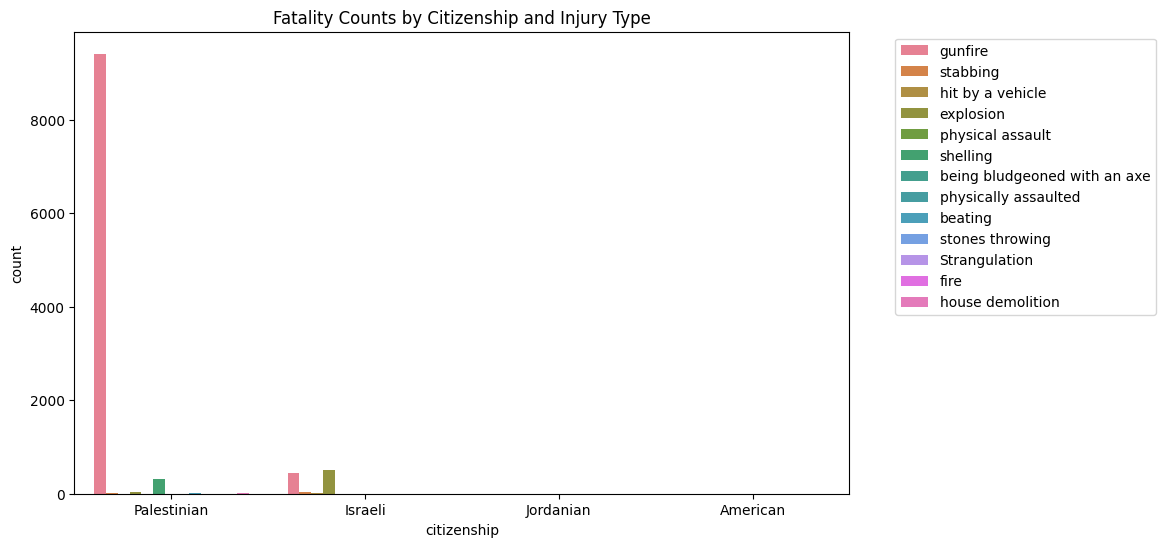

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using countplot instead of barplot for categorical distributions
plt.figure(figsize=(10, 6))
sns.countplot(x='citizenship', data=df, hue='type_of_injury')
plt.title('Fatality Counts by Citizenship and Injury Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

This count plot shows the ways of injury and way to murder people, exponentially being gunfire but as well shows the other means of murder of Palestinians that, not as large as the former, shows the heinous acts of Israel.